In [17]:
import dataclasses
import json
import os

import fsspec
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from experiments.evals.exp_isoflop_hf_logprobs import get_step_output_path
from experiments.evals.exp_isoflop_hf_math500 import build_hf_steps as build_base_eval_steps
from experiments.evals.math500_sft_sweep import (
    build_steps,
    process_math_train,
    ProcessMathTrainConfig,
    download_math_train_step,
)
from experiments.evals.exp1600_uncheatable_evals import models, get_directory_friendly_name
from experiments.evals.exp_isoflop_hf_math500_sft import DEFAULT_SFT_CONFIG, _read_eval_metrics
from marin.execution.executor import Executor, output_path_of, versioned, ExecutorStep, this_output_path

PREFIX = "gs://marin-us-central1"

In [18]:
# Reconstruct the same steps as main()
prompt_format = "standard_fewshot"
base_models = [models[0], models[6]]  # marin-8b, qwen-3-0.6b

sft_data = ExecutorStep(
    name="documents/math_train_sft",
    fn=process_math_train,
    config=ProcessMathTrainConfig(
        raw_data_path=output_path_of(download_math_train_step),
        output_path=this_output_path(),
        prompt_format=prompt_format,
    ),
    pip_dependency_groups=["math"],
)
sft_configs = {
    f"lr_{lr}_warmup_{warmup}": dataclasses.replace(
        DEFAULT_SFT_CONFIG, learning_rate=lr, warmup=warmup
    )
    for lr in [versioned(1e-5), versioned(5e-6), versioned(1e-6)]
    for warmup in [versioned(0.01), versioned(0.03), versioned(0.1)]
}

eval_steps = build_steps(
    sft_data=sft_data,
    sft_configs=sft_configs,
    base_models=base_models,
    prompt_format=prompt_format,
    prefix="math_sft_sweep",
)
print(f"{len(eval_steps)} eval steps")

`rope_scaling`'s original_max_position_embeddings field must be less than max_position_embeddings, got 8192 and max_position_embeddings=4096
`rope_scaling`'s original_max_position_embeddings field must be less than max_position_embeddings, got 8192 and max_position_embeddings=4096
2026-02-23 14:38:40,837	WARNING defaults.py:292 -- Truncated name from math_sft_sweep/math500_sft/marin-community--marin-8b-base----lr_VersionedValue(value=1e-05)_warmup_VersionedValue(value=0.01) to math_sft_sweep/math500_sft-05)_warmup_VersionedValue(value=0.01) to fit within WANDB limits.
2026-02-23 14:38:40,839	WARNING defaults.py:292 -- Truncated name from math_sft_sweep/math500_sft/marin-community--marin-8b-base----lr_VersionedValue(value=1e-05)_warmup_VersionedValue(value=0.03) to math_sft_sweep/math500_sft-05)_warmup_VersionedValue(value=0.03) to fit within WANDB limits.
2026-02-23 14:38:40,839	WARNING defaults.py:292 -- Truncated name from math_sft_sweep/math500_sft/marin-community--marin-8b-base----

36 eval steps


In [19]:
# Resolve output paths and read results
executor = Executor(prefix=PREFIX, executor_info_base_path=os.path.join(PREFIX, "experiments"))
for step in eval_steps:
    executor.compute_version(step, is_pseudo_dep=False)

rows = []
for model_config in base_models:
    directory_friendly_name = get_directory_friendly_name(model_config.model_name)
    for config_name, sft_config in sft_configs.items():
        # Read eval metrics once per SFT run (shared across best/latest)
        best_step_name = f"analysis/math_sft_sweep/math500_sft_rollouts/{directory_friendly_name}/{config_name}/best"
        best_step = [s for s in eval_steps if s.name == best_step_name][0]
        sft_step = best_step.config.sft_output_path.step
        sft_output_path = executor.output_paths[sft_step]
        eval_metrics = _read_eval_metrics(sft_output_path)
        eval_losses = [r["eval/loss"] for r in eval_metrics if "eval/loss" in r]

        for checkpoint_type in ["best", "latest"]:
            step_name = f"analysis/math_sft_sweep/math500_sft_rollouts/{directory_friendly_name}/{config_name}/{checkpoint_type}"
            matching = [s for s in eval_steps if s.name == step_name]
            step = matching[0]

            path = executor.output_paths[step]
            results_path = os.path.join(path, "results.json.gz")

            with fsspec.open(results_path, "rt", compression="gzip") as f:
                data = json.load(f)

            if checkpoint_type == "best":
                eval_loss = min(eval_losses)
            else:
                eval_loss = eval_losses[-1]

            rows.append({
                "model": directory_friendly_name,
                "config": config_name,
                "lr": sft_config.learning_rate.value,
                "warmup": sft_config.warmup.value,
                "checkpoint": checkpoint_type,
                "eval_loss": eval_loss,
                "pass_at_1": data["pass_at_1"],
                "pass_at_k": data["pass_at_k"],
                "k": data["k"],
            })

df = pd.DataFrame(rows)
print(f"Loaded {len(df)} results")
df

2026-02-23 14:38:43,703	WARNING executor.py:829 -- Output path gs://marin-us-central1/models/marin-community--marin-8b-base--main-61a5dc doesn't match given override models/marin-community--marin-8b-base--main, using the latter.
2026-02-23 14:38:43,706	WARNING executor.py:829 -- Output path gs://marin-us-central1/models/Qwen--Qwen3-0-6B--main-d4c23b doesn't match given override models/Qwen--Qwen3-0-6B--main, using the latter.


Loaded 36 results


,model,config,lr,warmup,checkpoint,eval_loss,pass_at_1,pass_at_k,k
0,marin-community--marin-8b-base,lr_VersionedValue(value=1e-05)_warmup_Versione...,0.000010,0.01,best,1.134388,0.1500,0.246,10
1,marin-community--marin-8b-base,lr_VersionedValue(value=1e-05)_warmup_Versione...,0.000010,0.01,latest,1.134388,0.1500,0.246,10
2,marin-community--marin-8b-base,lr_VersionedValue(value=1e-05)_warmup_Versione...,0.000010,0.03,best,1.092364,0.1516,0.256,10
3,marin-community--marin-8b-base,lr_VersionedValue(value=1e-05)_warmup_Versione...,0.000010,0.03,latest,1.092364,0.1516,0.256,10
4,marin-community--marin-8b-base,lr_VersionedValue(value=1e-05)_warmup_Versione...,0.000010,0.10,best,1.118985,0.1276,0.248,10
5,marin-community--marin-8b-base,lr_VersionedValue(value=1e-05)_warmup_Versione...,0.000010,0.10,latest,1.118985,0.1276,0.248,10
6,marin-community--marin-8b-base,lr_VersionedValue(value=5e-06)_warmup_Versione...,0.000005,0.01,best,1.288164,0.1402,0.266,10
7,marin-community--marin-8b-base,lr_VersionedValue(value=5e-06)_warmup_Versione...,0.000005,0.01,latest,1.288164,0.1402,0.266,10
8,marin-community--marin-8b-base,lr_VersionedValue(value=5e-06)_warmup_Versione...,0.000005,0.03,best,1.253104,0.1080,0.228,10
9,marin-community--marin-8b-base,lr_VersionedValue(value=5e-06)_warmup_Versione...,0.000005,0.03,latest,1.253104,0.1080,0.228,10


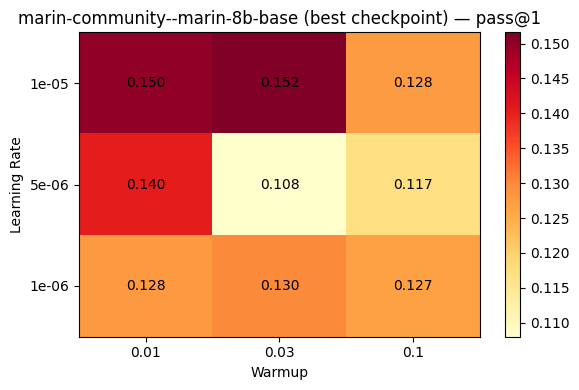

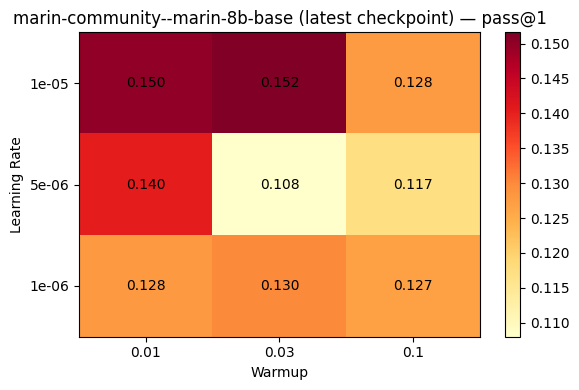

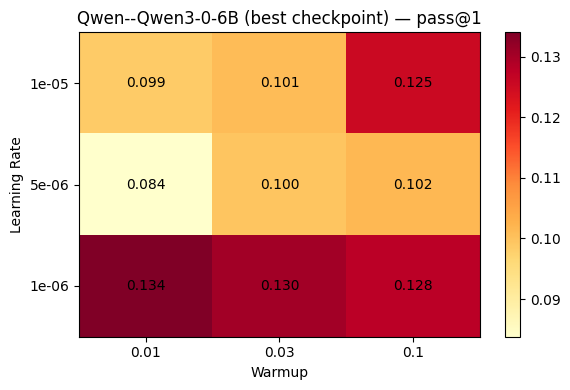

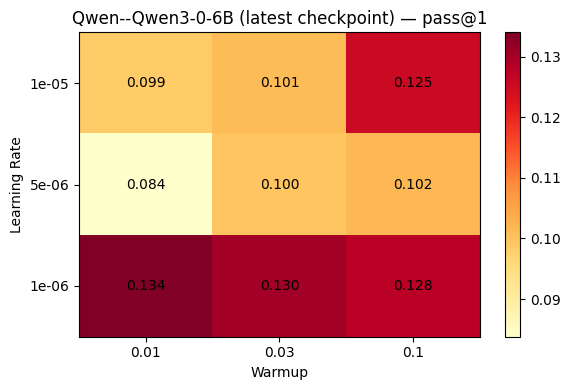

In [20]:
# Heatmap: pass@1 by lr x warmup
for model in df["model"].unique():
    for ckpt in ["best", "latest"]:
        subset = df[(df["model"] == model) & (df["checkpoint"] == ckpt)]
        if subset.empty:
            continue

        pivot = subset.pivot_table(index="lr", columns="warmup", values="pass_at_1")
        pivot = pivot.sort_index(ascending=False)

        fig, ax = plt.subplots(figsize=(6, 4))
        im = ax.imshow(pivot.values, cmap="YlOrRd", aspect="auto")

        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels([f"{w}" for w in pivot.columns])
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels([f"{lr:.0e}" for lr in pivot.index])

        for i in range(len(pivot.index)):
            for j in range(len(pivot.columns)):
                val = pivot.values[i, j]
                if not np.isnan(val):
                    ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=10)

        ax.set_xlabel("Warmup")
        ax.set_ylabel("Learning Rate")
        ax.set_title(f"{model} ({ckpt} checkpoint) — pass@1")
        fig.colorbar(im)
        plt.tight_layout()
        plt.show()

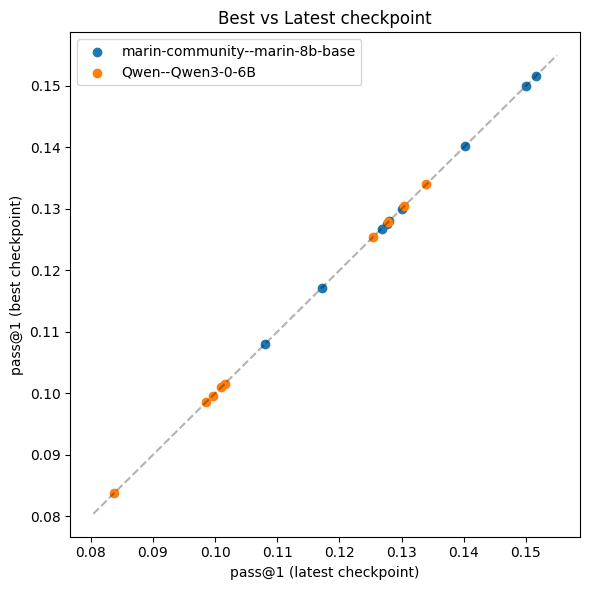

In [21]:
# Best vs latest checkpoint comparison
best_df = df[df["checkpoint"] == "best"].set_index(["model", "config"])["pass_at_1"]
latest_df = df[df["checkpoint"] == "latest"].set_index(["model", "config"])["pass_at_1"]
compare = pd.DataFrame({"best": best_df, "latest": latest_df}).dropna()

fig, ax = plt.subplots(figsize=(6, 6))
for model in df["model"].unique():
    model_compare = compare.loc[model]
    ax.scatter(model_compare["latest"], model_compare["best"], label=model)

lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, "k--", alpha=0.3)
ax.set_xlabel("pass@1 (latest checkpoint)")
ax.set_ylabel("pass@1 (best checkpoint)")
ax.set_title("Best vs Latest checkpoint")
ax.legend()
plt.tight_layout()
plt.show()

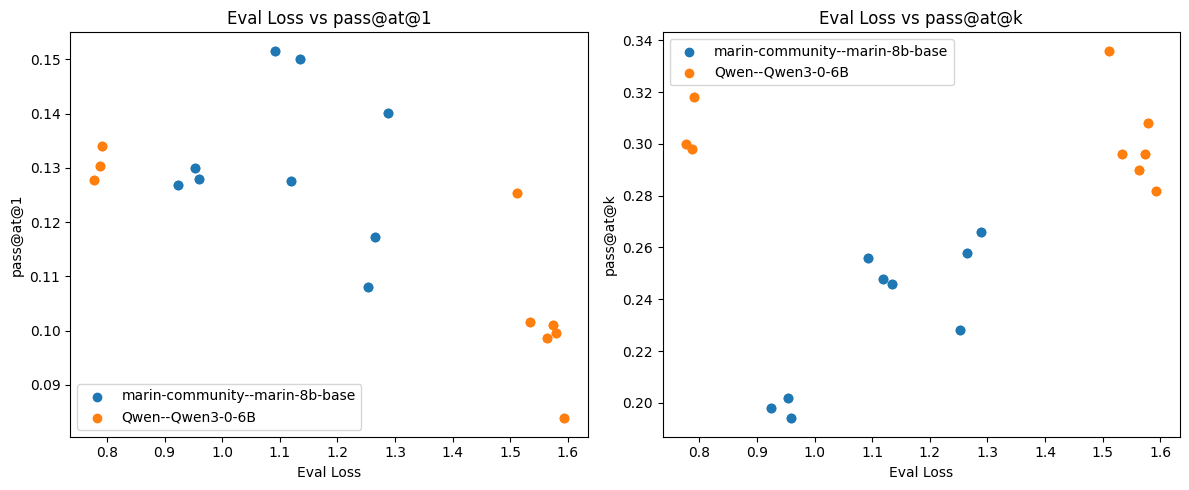

In [22]:
# Eval loss vs pass@1 and pass@k
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, metric in zip(axes, ["pass_at_1", "pass_at_k"]):
    for model in df["model"].unique():
        subset = df[df["model"] == model]
        ax.scatter(subset["eval_loss"], subset[metric], label=model)
    ax.set_xlabel("Eval Loss")
    ax.set_ylabel(metric.replace("_", "@"))
    ax.set_title(f"Eval Loss vs {metric.replace('_', '@')}")
    ax.legend()

plt.tight_layout()
plt.show()

2026-02-23 14:39:08,772	WARNING executor.py:829 -- Output path gs://marin-us-central1/models/marin-community--marin-8b-base--main-61a5dc doesn't match given override models/marin-community--marin-8b-base--main, using the latter.
2026-02-23 14:39:08,772	WARNING executor.py:844 -- Multiple `ExecutorStep`s (named models/marin-community--marin-8b-base--main) have the same version; try to instantiate only once.
2026-02-23 14:39:08,943	WARNING executor.py:829 -- Output path gs://marin-us-central1/models/Qwen--Qwen3-0-6B--main-d4c23b doesn't match given override models/Qwen--Qwen3-0-6B--main, using the latter.
2026-02-23 14:39:08,943	WARNING executor.py:844 -- Multiple `ExecutorStep`s (named models/Qwen--Qwen3-0-6B--main) have the same version; try to instantiate only once.


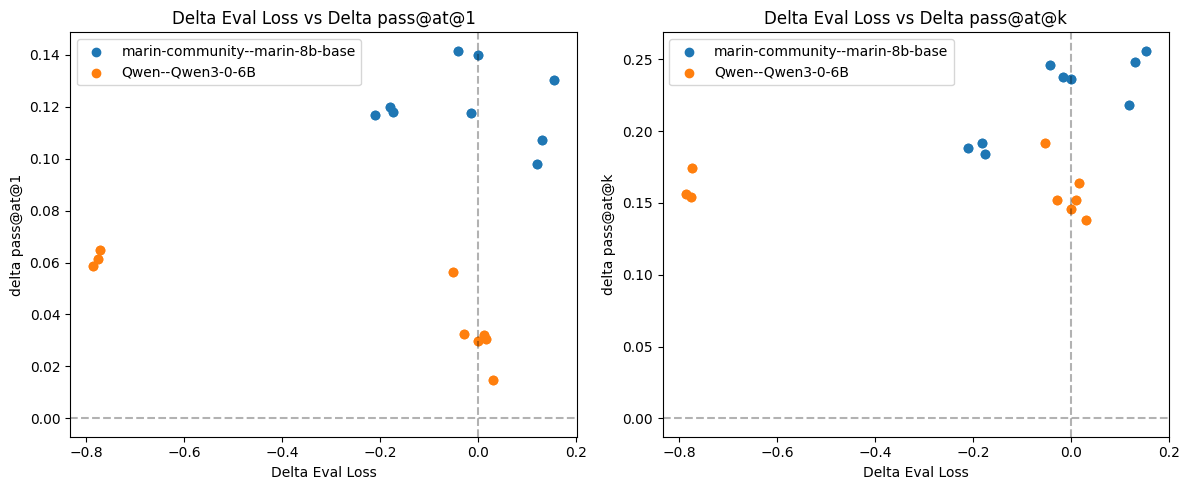

In [23]:
# Load base model MATH-500 results and compute baselines
base_model_names = {get_directory_friendly_name(m.model_name) for m in base_models}
base_eval_steps = build_base_eval_steps(prompt_format="standard_fewshot")

baselines = {}
for step in base_eval_steps:
    model_name = step.name.split("/")[-1]
    if model_name not in base_model_names:
        continue
    executor.compute_version(step, is_pseudo_dep=False)
    path = executor.output_paths[step]
    with fsspec.open(os.path.join(path, "results.json.gz"), "rt", compression="gzip") as f:
        data = json.load(f)
    baselines[model_name] = {"pass_at_1": data["pass_at_1"], "pass_at_k": data["pass_at_k"]}

# Get step-0 eval loss as baseline eval loss per model (from first SFT config)
for model_config in base_models:
    model_name = get_directory_friendly_name(model_config.model_name)
    first_config_name = next(iter(sft_configs))
    step_name = f"analysis/math_sft_sweep/math500_sft_rollouts/{model_name}/{first_config_name}/best"
    step = [s for s in eval_steps if s.name == step_name][0]
    sft_output_path = executor.output_paths[step.config.sft_output_path.step]
    eval_metrics = _read_eval_metrics(sft_output_path)
    first_loss = next(r["eval/loss"] for r in eval_metrics if "eval/loss" in r)
    baselines[model_name]["eval_loss"] = first_loss

# Compute deltas
df["delta_pass_at_1"] = df.apply(lambda r: r["pass_at_1"] - baselines[r["model"]]["pass_at_1"], axis=1)
df["delta_pass_at_k"] = df.apply(lambda r: r["pass_at_k"] - baselines[r["model"]]["pass_at_k"], axis=1)
df["delta_eval_loss"] = df.apply(lambda r: r["eval_loss"] - baselines[r["model"]]["eval_loss"], axis=1)

# Scatterplot: delta eval loss vs delta pass@1 and delta pass@k
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, metric in zip(axes, ["delta_pass_at_1", "delta_pass_at_k"]):
    for model in df["model"].unique():
        subset = df[df["model"] == model]
        ax.scatter(subset["delta_eval_loss"], subset[metric], label=model)
    ax.axhline(0, color="k", linestyle="--", alpha=0.3)
    ax.axvline(0, color="k", linestyle="--", alpha=0.3)
    ax.set_xlabel("Delta Eval Loss")
    ax.set_ylabel(metric.replace("_", "@").replace("delta@", "delta "))
    ax.set_title(f"Delta Eval Loss vs Delta {metric.split('_', 1)[1].replace('_', '@')}")
    ax.legend()

plt.tight_layout()
plt.show()

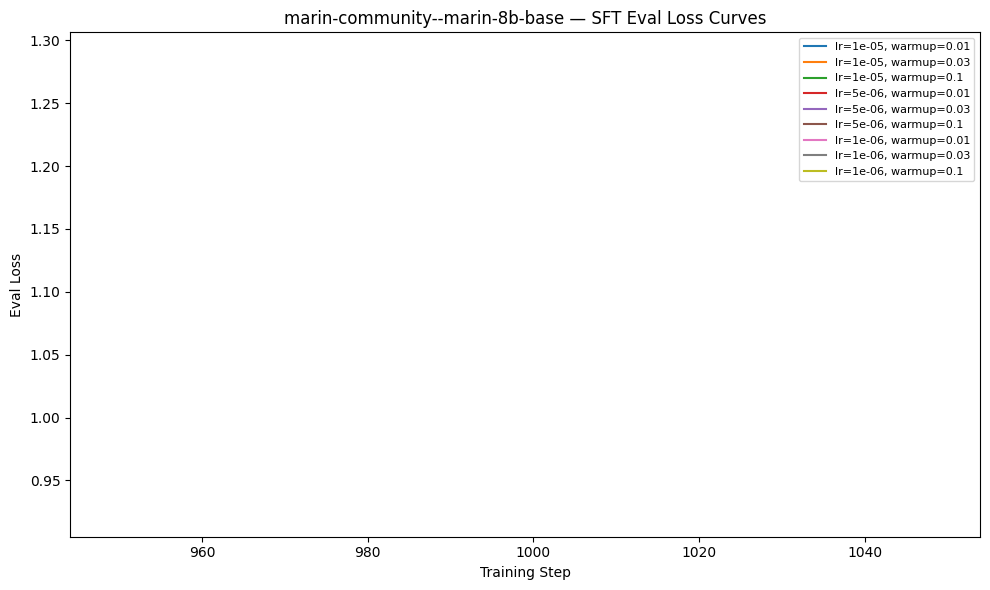

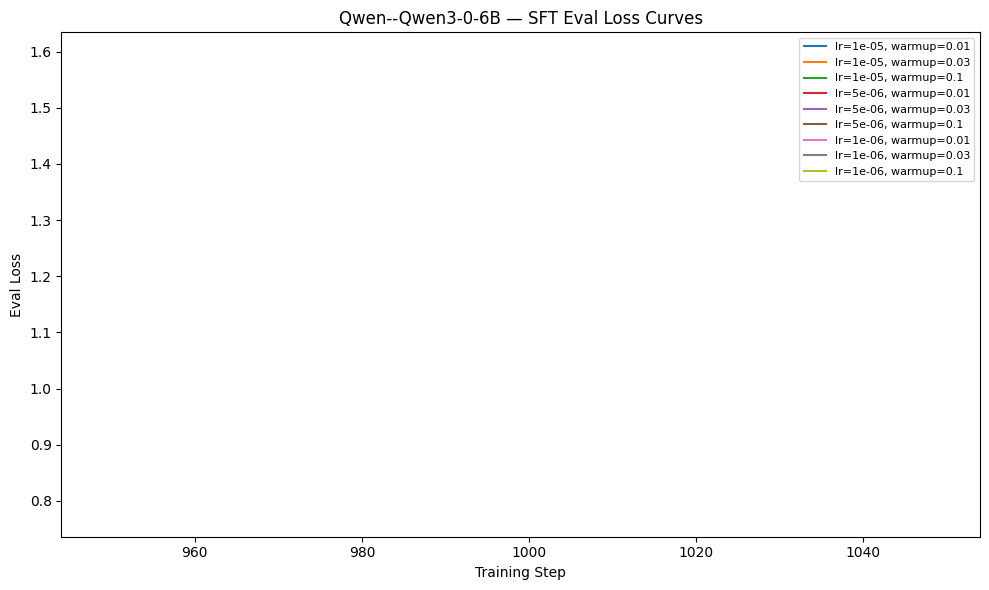

In [24]:
# SFT eval loss learning curves (one plot per model)
for model_config in base_models:
    model_name = get_directory_friendly_name(model_config.model_name)
    fig, ax = plt.subplots(figsize=(10, 6))

    for config_name, sft_config in sft_configs.items():
        step_name = f"analysis/math_sft_sweep/math500_sft_rollouts/{model_name}/{config_name}/best"
        step = [s for s in eval_steps if s.name == step_name][0]
        sft_output_path = executor.output_paths[step.config.sft_output_path.step]
        eval_metrics = _read_eval_metrics(sft_output_path)

        steps = [r["step"] for r in eval_metrics if "eval/loss" in r]
        losses = [r["eval/loss"] for r in eval_metrics if "eval/loss" in r]

        lr = sft_config.learning_rate.value
        warmup = sft_config.warmup.value
        ax.plot(steps, losses, label=f"lr={lr:.0e}, warmup={warmup}")

    ax.set_xlabel("Training Step")
    ax.set_ylabel("Eval Loss")
    ax.set_title(f"{model_name} — SFT Eval Loss Curves")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

In [26]:
len(eval_metrics)

1

In [27]:
sft_output_path

'gs://marin-us-central1/checkpoints/math_sft_sweep/math500_sft/-06)_warmup_VersionedValue(value=0.1)-2ba30e'

In [28]:

# Debug: check eval_metrics for first model/config
model_name = get_directory_friendly_name(base_models[0].model_name)
first_config_name = next(iter(sft_configs))
step_name = f"analysis/math_sft_sweep/math500_sft_rollouts/{model_name}/{first_config_name}/best"
step = [s for s in eval_steps if s.name == step_name][0]
sft_output_path = executor.output_paths[step.config.sft_output_path.step]
print(f"SFT output path: {sft_output_path}")
eval_metrics = _read_eval_metrics(sft_output_path)
print(f"Number of records: {len(eval_metrics)}")
if eval_metrics:
    print(f"First record keys: {eval_metrics[0].keys()}")
    print(f"First record: {eval_metrics[0]}")
    has_eval_loss = [r for r in eval_metrics if "eval/loss" in r]
    print(f"Records with eval/loss: {len(has_eval_loss)}")
    if has_eval_loss:
        print(f"First eval/loss record: {has_eval_loss[0]}")


SFT output path: gs://marin-us-central1/checkpoints/math_sft_sweep/math500_sft-05)_warmup_VersionedValue(value=0.01)-c7a484
Number of records: 1
First record keys: dict_keys(['eval/bpb', 'eval/loading_time', 'eval/loss', 'eval/marin-community--marin-8b-base/bpb', 'eval/marin-community--marin-8b-base/loss', 'eval/total_time', 'step'])
First record: {'eval/bpb': 0.6457186937332153, 'eval/loading_time': 0.1390280309933587, 'eval/loss': 1.1343883275985718, 'eval/marin-community--marin-8b-base/bpb': 0.6457186937332153, 'eval/marin-community--marin-8b-base/loss': 1.1343883275985718, 'eval/total_time': 27.408124839996162, 'step': 999}
Records with eval/loss: 1
First eval/loss record: {'eval/bpb': 0.6457186937332153, 'eval/loading_time': 0.1390280309933587, 'eval/loss': 1.1343883275985718, 'eval/marin-community--marin-8b-base/bpb': 0.6457186937332153, 'eval/marin-community--marin-8b-base/loss': 1.1343883275985718, 'eval/total_time': 27.408124839996162, 'step': 999}
